# Introduction
The dataset consists of numerical samples used for supervised learning.
Each row represents one observation, identified by a unique ID.

## Structure

### Training Set:
$$ID, INPUT_0, INPUT_1, ..., INPUT_{N-1}, TARGET_0, TARGET_1, TARGET_2, TARGET_3$$
Contains both input features and corresponding target values.

So $$X = (x_i) = (INPUT_0, INPUT_1, ..., INPUT_{N-1}) \quad i=1..500, N=12$$ and $$y_i=(TARGET_0, TARGET_1, TARGET_2, TARGET_3)\quad i=1..500$$

### Blind Test Set:
$$ID, INPUT_1, INPUT_2, ..., INPUT_N$$
Contains only input features; target values are omitted.

# 1. Training set analysis

In [3]:
## in the ML-CUP25-TR.csv comment is explained the shape of the dataset
n_inputs = 12

## Training set: ID, INPUTS, TARGET_1, TARGET_2, TARGET_3, TARGET_4 (last 4 columns)
columns = (
    ["ID"] +
    [f"INPUT_{i}" for i in range(n_inputs)] +
    [f"TARGET_{i}" for i in range(4)]
)

In [4]:
import pandas as pd
import numpy as np

ml_cup_tr = pd.read_csv("./data/MLC25/ML-CUP25-TR.csv", skiprows=7, names=columns)
ml_cup_tr.drop(columns=["ID"])

,INPUT_0,INPUT_1,INPUT_2,INPUT_3,INPUT_4,INPUT_5,INPUT_6,INPUT_7,INPUT_8,INPUT_9,INPUT_10,INPUT_11,TARGET_0,TARGET_1,TARGET_2,TARGET_3
0,-6.925642,-6.093158,-9.149763,-5.918488,4.391259,-1.059304,-5.031085,-6.932177,-5.805652,7.147028,4.555533,-5.694865,6.554997,10.688732,15.416160,-7.535628
1,-5.649870,-7.650998,-10.407383,-7.864047,3.790306,-1.673732,-8.493233,-8.143588,-9.447557,10.790796,6.266211,-5.551301,12.342252,-8.135250,23.787661,-3.270978
2,15.985886,14.192953,24.466835,12.551305,-7.788409,0.557977,23.145951,20.031774,14.516358,-21.024198,-10.410913,12.061133,28.542661,-14.132383,-56.408372,1.892238
3,12.774004,10.156462,18.588934,8.346695,-5.245173,-0.199274,14.500231,12.608063,12.411055,-15.479452,-8.871887,6.703585,20.253500,9.525402,-0.673842,40.295464
4,-4.019226,-4.043457,-5.095354,-3.147125,0.725466,-0.477673,-4.025913,-0.995364,-3.491760,3.385533,1.838361,-4.271710,-3.588910,6.050010,1.198489,-11.677909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-7.843406,-7.094219,-14.356348,-6.721251,3.115052,-2.392241,-8.837664,-6.470696,-5.807141,9.754465,6.840160,-6.912569,14.093165,-4.845333,19.188406,-8.091055
496,15.792855,16.891394,27.492396,11.092835,-10.404277,1.038514,20.856860,20.624264,15.586675,-16.882227,-10.420515,10.612868,13.546922,27.986044,-7.274439,49.639830
497,13.200066,12.638262,26.459051,11.366576,-9.165648,1.587006,20.433137,20.044718,15.032366,-17.307257,-10.692552,10.053785,-11.158948,-27.368210,-22.150507,31.950889
498,-7.147499,-10.617766,-17.635645,-7.378656,5.586325,-3.656751,-7.872403,-9.290113,-8.199866,11.160446,5.605515,-6.487252,17.969044,2.482662,31.653539,-1.551031


In [5]:
ml_cup_tr.shape

(500, 17)

In [6]:
ml_cup_tr.describe()

,ID,INPUT_0,INPUT_1,INPUT_2,INPUT_3,INPUT_4,INPUT_5,INPUT_6,INPUT_7,INPUT_8,INPUT_9,INPUT_10,INPUT_11,TARGET_0,TARGET_1,TARGET_2,TARGET_3
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2.192591,1.985201,2.964003,1.253766,-1.157977,-1.047810,3.338381,3.719711,1.865092,-2.010697,-1.099971,0.934127,0.389428,-0.327295,-3.902642,3.539920
std,144.481833,10.286317,9.963656,16.469568,8.798678,5.810382,1.472323,13.665820,11.613106,10.294106,12.548332,6.748874,7.190852,14.513931,14.649640,22.799458,22.826463
min,1.000000,-14.186211,-13.501160,-22.965501,-12.141768,-11.183458,-4.526356,-18.188538,-14.398808,-13.598290,-21.862883,-12.030295,-10.442014,-33.127872,-31.947674,-61.263947,-43.153797
25%,125.750000,-7.908818,-7.851909,-12.979454,-7.097901,-6.725810,-2.025779,-10.082701,-7.309813,-8.317647,-13.958565,-7.597680,-6.156146,-10.337636,-12.406667,-19.166902,-9.375774
50%,250.500000,1.332915,1.098132,0.667491,-0.099914,-0.774233,-1.155767,1.468290,3.103896,0.834996,-1.196129,-0.546028,0.280869,0.693273,0.222676,-0.019050,0.022572
75%,375.250000,12.523027,11.849832,18.611940,9.995148,4.425014,0.161375,16.466172,15.283986,11.838149,10.357157,5.671498,8.039433,11.584963,11.755558,10.176255,18.054295
max,500.000000,19.348318,18.005390,29.436493,15.307485,8.425326,1.987429,26.351188,23.475931,18.488262,17.075664,9.078277,12.621792,31.584418,30.854478,42.274126,59.345224


In [7]:
X_tr = ml_cup_tr[[f"INPUT_{i}" for i in range(n_inputs)]].values
y_tr = ml_cup_tr[[f"TARGET_{i}" for i in range(4)]].values

In [8]:
X_tr.shape

(500, 12)

In [9]:
y_tr.shape

(500, 4)

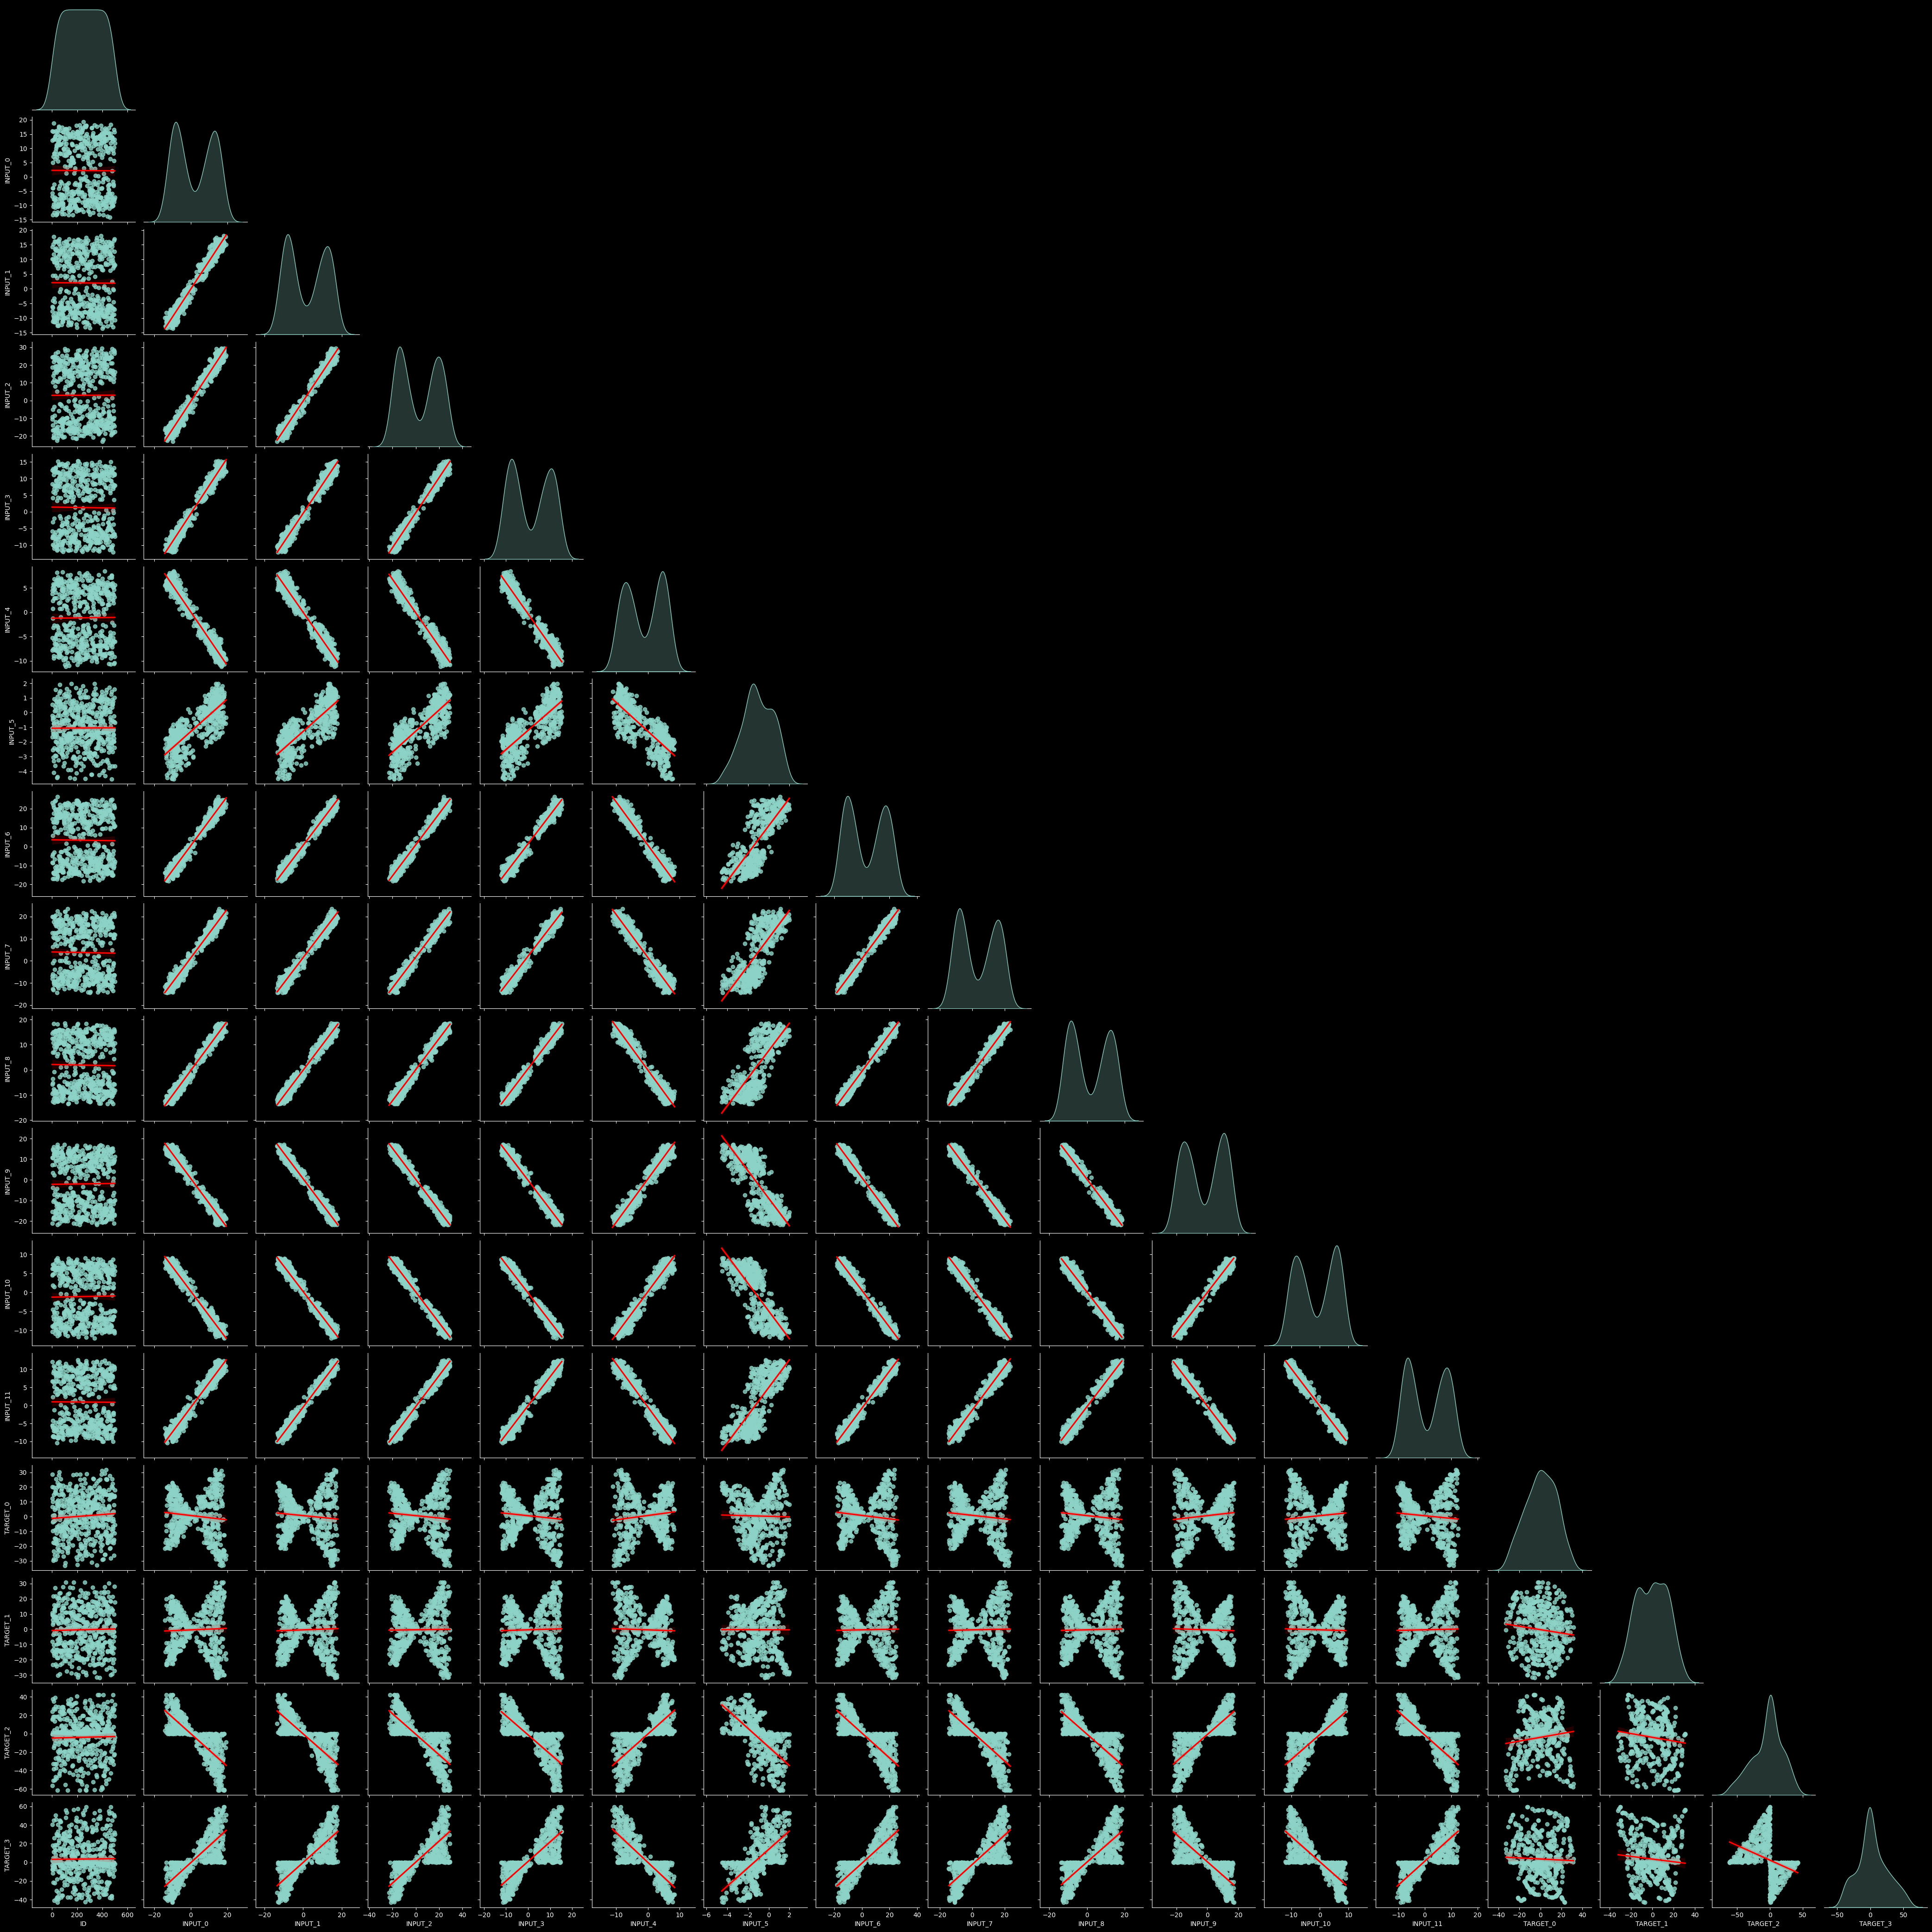

In [10]:
import seaborn as sbn

sbn.pairplot(ml_cup_tr, diag_kind="kde", kind="reg", corner=True, plot_kws={'line_kws':{'color':'red'}})

<Axes: >

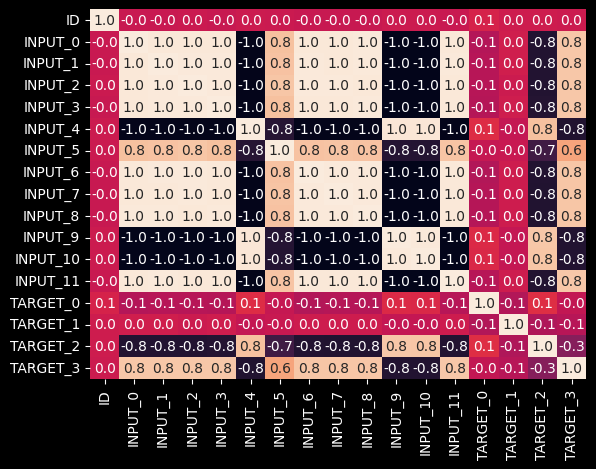

In [11]:
sbn.heatmap(ml_cup_tr.corr(), cbar = False, annot = True, fmt=".1f")

## Preprocessing

The golden rule is
> - If your model is sensitive to feature magnitude (like neural networks, KNN, gradient boosting): 
>   - MinMaxScaler is usually best. 
> - If your model assumes normal distribution or uses distance metrics, 
>   - StandardScaler is usually better.

In [12]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import *

In [13]:
def plot_dataset_scaling(X, label):
    n_features = X.shape[1]
    for i in range(n_features):
        plt.hist(X[:, i], alpha=0.4, label=f"input_{i}")
    plt.legend(loc='upper right', ncol=3)
    if label:
        plt.title(label)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

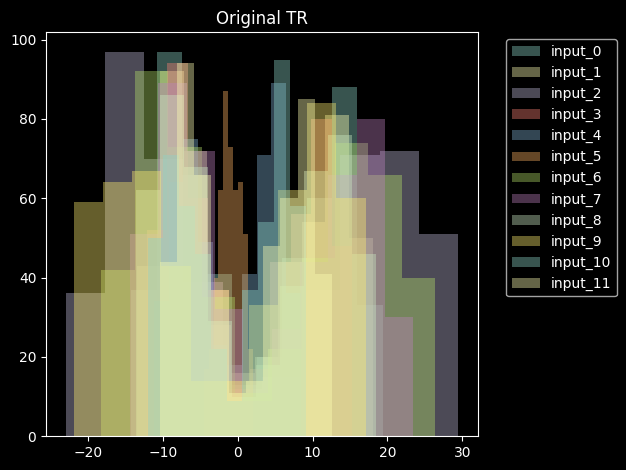

In [14]:
plot_dataset_scaling(X_tr, "Original TR")

### 1. MinMaxScaler
- Rescales features to a fixed range (usually 0–1 or -1–1). 
  - Preserves the shape of the original distribution but compresses values.
- Use when all features should have equal weight and you know the min/max bounds (e.g., neural networks).

In [15]:
scaler = MinMaxScaler()
scaler.fit(X_tr)
X_tr_scaled = scaler.transform(X_tr)

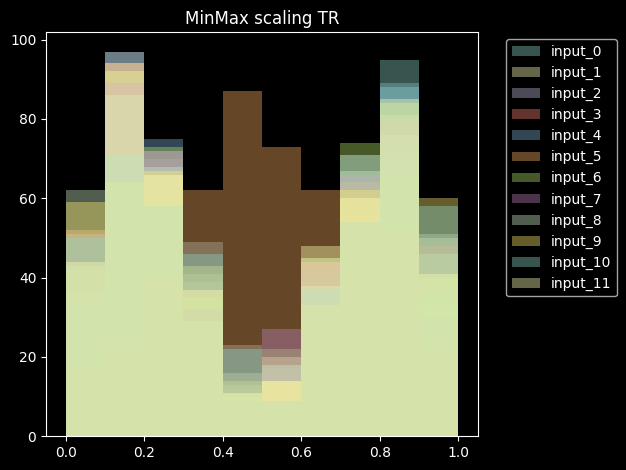

In [16]:
plot_dataset_scaling(X_tr_scaled, "MinMax scaling TR")

In [17]:
pd.DataFrame(X_tr).describe()

,0,1,2,3,4,5,6,7,8,9,10,11
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.192591,1.985201,2.964003,1.253766,-1.157977,-1.047810,3.338381,3.719711,1.865092,-2.010697,-1.099971,0.934127
std,10.286317,9.963656,16.469568,8.798678,5.810382,1.472323,13.665820,11.613106,10.294106,12.548332,6.748874,7.190852
min,-14.186211,-13.501160,-22.965501,-12.141768,-11.183458,-4.526356,-18.188538,-14.398808,-13.598290,-21.862883,-12.030295,-10.442014
25%,-7.908818,-7.851909,-12.979454,-7.097901,-6.725810,-2.025779,-10.082701,-7.309813,-8.317647,-13.958565,-7.597680,-6.156146
50%,1.332915,1.098132,0.667491,-0.099914,-0.774233,-1.155767,1.468290,3.103896,0.834996,-1.196129,-0.546028,0.280869
75%,12.523027,11.849832,18.611940,9.995148,4.425014,0.161375,16.466172,15.283986,11.838149,10.357157,5.671498,8.039433
max,19.348318,18.005390,29.436493,15.307485,8.425326,1.987429,26.351188,23.475931,18.488262,17.075664,9.078277,12.621792


In [18]:
pd.DataFrame(X_tr_scaled).describe()

,0,1,2,3,4,5,6,7,8,9,10,11
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.488416,0.491528,0.494819,0.488011,0.511275,0.534028,0.483320,0.478380,0.481927,0.509834,0.517814,0.493246
std,0.306738,0.316241,0.314293,0.320543,0.296315,0.226032,0.306823,0.306619,0.320823,0.322260,0.319722,0.311781
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.187192,0.179304,0.190566,0.183752,0.227329,0.383890,0.181991,0.187169,0.164575,0.202995,0.209991,0.185827
50%,0.462780,0.463373,0.450994,0.438695,0.530845,0.517455,0.441332,0.462121,0.449824,0.530753,0.544057,0.464923
75%,0.796470,0.804626,0.793432,0.806467,0.795994,0.719663,0.778063,0.783710,0.792745,0.827459,0.838607,0.801318
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Capiamo se ci sono tanti outlier utilizzando il Z-score, visto che ora abbiamo dati normalizzati.

In [19]:
means = np.mean(X_tr_scaled, axis=0)
stds = np.std(X_tr_scaled, axis=0)

z_scores_minmax = (X_tr_scaled - means) / stds

In [20]:
# Calcola il valore assoluto degli Z-score
abs_z_scores = np.abs(z_scores_minmax)

# Crea una maschera per i valori che superano la soglia di 3
outlier_mask = abs_z_scores > 3

# Conta quanti outlier sono presenti
numero_totale_outlier = np.sum(outlier_mask)
print(f"Outlier rilevati: {numero_totale_outlier}")

Outlier rilevati: 0


### 2. StandardScaler

- Centers data at mean 0 with unit variance (Z-score normalization). 
  - Keeps the relative shape, but shifts and scales by mean and standard deviation.
- Use when data may contain outliers or unknown range, or algorithms assume normality (e.g., linear/logistic regression, PCA, SVM).

In [21]:
scaler = StandardScaler()
scaler.fit(X_tr)
X_tr_scaled = scaler.transform(X_tr)

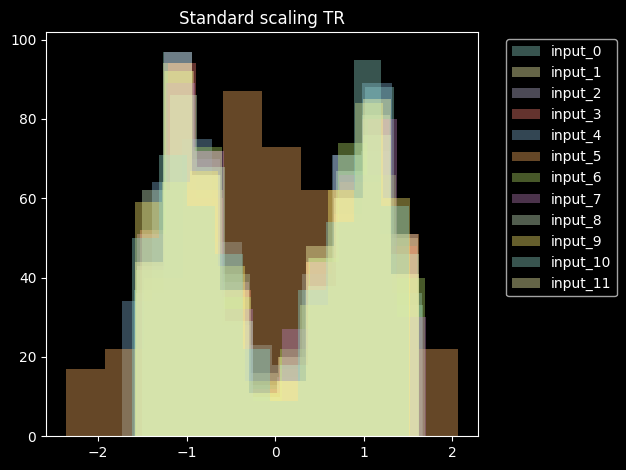

In [22]:
plot_dataset_scaling(X_tr_scaled, "Standard scaling TR")

In [23]:
pd.DataFrame(X_tr).describe()

,0,1,2,3,4,5,6,7,8,9,10,11
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.192591,1.985201,2.964003,1.253766,-1.157977,-1.047810,3.338381,3.719711,1.865092,-2.010697,-1.099971,0.934127
std,10.286317,9.963656,16.469568,8.798678,5.810382,1.472323,13.665820,11.613106,10.294106,12.548332,6.748874,7.190852
min,-14.186211,-13.501160,-22.965501,-12.141768,-11.183458,-4.526356,-18.188538,-14.398808,-13.598290,-21.862883,-12.030295,-10.442014
25%,-7.908818,-7.851909,-12.979454,-7.097901,-6.725810,-2.025779,-10.082701,-7.309813,-8.317647,-13.958565,-7.597680,-6.156146
50%,1.332915,1.098132,0.667491,-0.099914,-0.774233,-1.155767,1.468290,3.103896,0.834996,-1.196129,-0.546028,0.280869
75%,12.523027,11.849832,18.611940,9.995148,4.425014,0.161375,16.466172,15.283986,11.838149,10.357157,5.671498,8.039433
max,19.348318,18.005390,29.436493,15.307485,8.425326,1.987429,26.351188,23.475931,18.488262,17.075664,9.078277,12.621792


In [24]:
# apply(...) to suppress scientific notation, otherwise is confusonary
pd.DataFrame(X_tr_scaled).describe().apply(lambda s: s.apply(lambda x: format(x, 'g')))

,0,1,2,3,4,5,6,7,8,9,10,11
count,500,500,500,500,500,500,500,500,500,500,500,500
mean,-1.77636e-17,-2.4869e-17,3.01981e-17,-2.13163e-17,4.26326e-17,9.23706e-17,1.42109e-17,-4.26326e-17,4.61853e-17,5.68434e-17,-3.55271e-17,4.26326e-17
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.59388,-1.55584,-1.57597,-1.52397,-1.72717,-2.36499,-1.57682,-1.56174,-1.50366,-1.58364,-1.6212,-1.58361
25%,-0.983007,-0.988288,-0.969025,-0.950146,-0.959216,-0.664901,-0.983075,-0.950699,-0.990172,-0.953101,-0.963748,-0.987
50%,-0.0836585,-0.0891197,-0.139579,-0.154004,0.0661107,-0.0733976,-0.136981,-0.0530807,-0.100167,0.0649794,0.0821615,-0.0909367
75%,1.00529,0.991053,0.951064,0.994483,0.961827,0.8221,0.961592,0.996792,0.969783,0.986604,1.00435,0.989093
max,1.66949,1.60947,1.60897,1.59885,1.65099,2.0636,1.68565,1.7029,1.61644,1.52255,1.50965,1.62698


# 2. Test set analysis

In [25]:
## in the ML-CUP25-TS.csv comment is explained the shape of the dataset
n_inputs = 12

## Test set: ID, INPUTS
columns = (
    ["ID"] +
    [f"INPUT_{i}" for i in range(n_inputs)]
)

In [26]:
import pandas as pd

ml_cup_ts = pd.read_csv("./data/MLC25/ML-CUP25-TS.csv", skiprows=7, names=columns)

In [27]:
ml_cup_ts.describe()

,ID,INPUT_0,INPUT_1,INPUT_2,INPUT_3,INPUT_4,INPUT_5,INPUT_6,INPUT_7,INPUT_8,INPUT_9,INPUT_10,INPUT_11
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2.404306,2.158814,3.110398,1.405292,-1.281809,-1.121183,3.477296,3.850756,2.005623,-2.157151,-1.191236,1.004080
std,288.819436,10.408475,9.950216,16.444797,8.800982,5.865419,1.470547,13.792672,11.680837,10.268945,12.511419,6.756609,7.109364
min,1.000000,-14.229968,-13.470526,-23.414692,-12.420594,-11.577754,-4.600196,-17.943180,-14.730689,-14.168120,-21.993543,-12.105692,-10.357583
25%,250.750000,-7.421046,-7.700048,-13.075671,-7.173541,-7.135307,-2.235450,-9.936012,-7.641318,-8.236345,-14.362077,-7.906127,-5.948207
50%,500.500000,1.314727,0.721810,1.606648,0.503870,-0.727214,-1.134166,1.237376,2.499016,0.186988,-0.331649,-0.070094,-0.239565
75%,750.250000,12.757383,11.905664,19.645101,9.917579,4.365970,0.106489,17.011635,15.489725,12.194928,10.199556,5.480519,8.100701
max,1000.000000,19.360612,17.837861,29.528274,15.958363,8.126146,2.068208,26.246359,23.964058,18.819681,17.466061,9.402062,13.005717


In [28]:
X_ts = ml_cup_ts[[f"INPUT_{i}" for i in range(n_inputs)]].values

In [29]:
X_ts.shape

(1000, 12)

## Preprocessing

The golden rule is
> - If your model is sensitive to feature magnitude (like neural networks, KNN, gradient boosting): 
>   - MinMaxScaler is usually best. 
> - If your model assumes normal distribution or uses distance metrics, 
>   - StandardScaler is usually better.

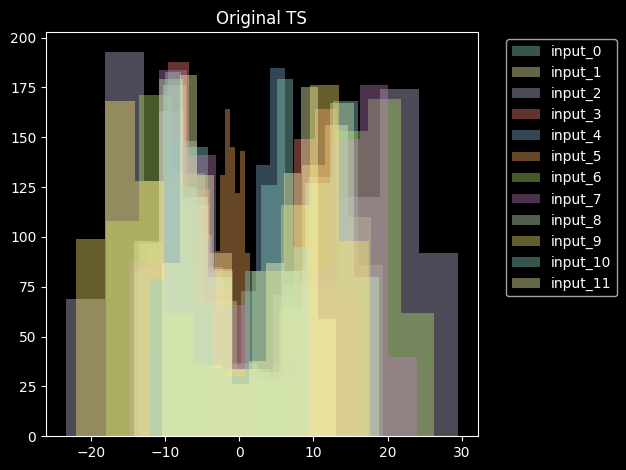

In [30]:
plot_dataset_scaling(X_ts, "Original TS")

## 1. MinMax Scaling

In [31]:
scaler = MinMaxScaler()
scaler.fit(X_ts)
X_ts_scaled = scaler.transform(X_ts)

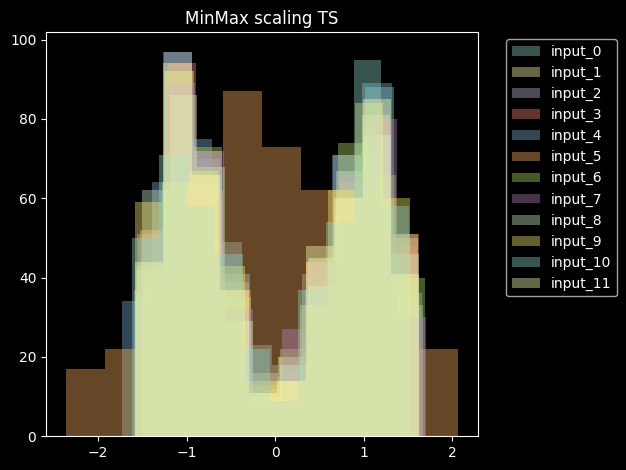

In [32]:
plot_dataset_scaling(X_tr_scaled, "MinMax scaling TS")

In [33]:
pd.DataFrame(X_ts).describe()

,0,1,2,3,4,5,6,7,8,9,10,11
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.404306,2.158814,3.110398,1.405292,-1.281809,-1.121183,3.477296,3.850756,2.005623,-2.157151,-1.191236,1.004080
std,10.408475,9.950216,16.444797,8.800982,5.865419,1.470547,13.792672,11.680837,10.268945,12.511419,6.756609,7.109364
min,-14.229968,-13.470526,-23.414692,-12.420594,-11.577754,-4.600196,-17.943180,-14.730689,-14.168120,-21.993543,-12.105692,-10.357583
25%,-7.421046,-7.700048,-13.075671,-7.173541,-7.135307,-2.235450,-9.936012,-7.641318,-8.236345,-14.362077,-7.906127,-5.948207
50%,1.314727,0.721810,1.606648,0.503870,-0.727214,-1.134166,1.237376,2.499016,0.186988,-0.331649,-0.070094,-0.239565
75%,12.757383,11.905664,19.645101,9.917579,4.365970,0.106489,17.011635,15.489725,12.194928,10.199556,5.480519,8.100701
max,19.360612,17.837861,29.528274,15.958363,8.126146,2.068208,26.246359,23.964058,18.819681,17.466061,9.402062,13.005717


In [34]:
pd.DataFrame(X_ts_scaled).describe()

,0,1,2,3,4,5,6,7,8,9,10,11
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.495207,0.499206,0.501013,0.487188,0.522533,0.521716,0.484741,0.480206,0.490295,0.502701,0.507466,0.486304
std,0.309863,0.317813,0.310613,0.310124,0.297678,0.220525,0.312125,0.301871,0.311295,0.317069,0.314148,0.304296
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.202703,0.184311,0.195286,0.184892,0.225460,0.354620,0.181201,0.183213,0.179817,0.193399,0.195258,0.188731
50%,0.462769,0.453308,0.472609,0.455424,0.550680,0.519769,0.434052,0.445272,0.435164,0.548964,0.559593,0.433073
75%,0.803420,0.810524,0.813324,0.787139,0.809166,0.705819,0.791020,0.780995,0.799176,0.815850,0.817668,0.790055
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 2. StandardScaler

In [35]:
scaler = StandardScaler()
scaler.fit(X_ts)
X_ts_scaled = scaler.transform(X_ts)

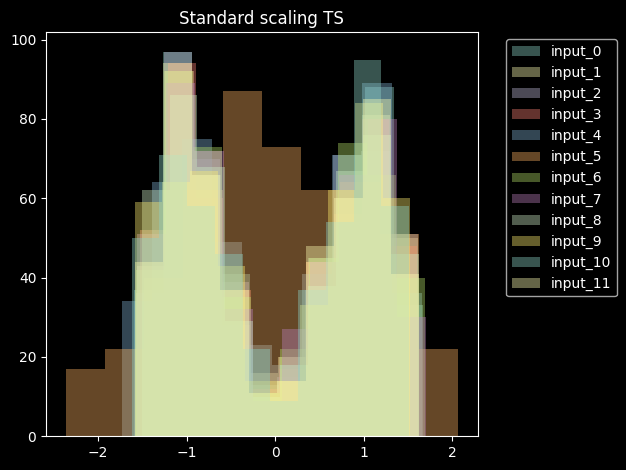

In [36]:
plot_dataset_scaling(X_tr_scaled, "Standard scaling TS")

In [37]:
pd.DataFrame(X_ts).describe()

,0,1,2,3,4,5,6,7,8,9,10,11
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.404306,2.158814,3.110398,1.405292,-1.281809,-1.121183,3.477296,3.850756,2.005623,-2.157151,-1.191236,1.004080
std,10.408475,9.950216,16.444797,8.800982,5.865419,1.470547,13.792672,11.680837,10.268945,12.511419,6.756609,7.109364
min,-14.229968,-13.470526,-23.414692,-12.420594,-11.577754,-4.600196,-17.943180,-14.730689,-14.168120,-21.993543,-12.105692,-10.357583
25%,-7.421046,-7.700048,-13.075671,-7.173541,-7.135307,-2.235450,-9.936012,-7.641318,-8.236345,-14.362077,-7.906127,-5.948207
50%,1.314727,0.721810,1.606648,0.503870,-0.727214,-1.134166,1.237376,2.499016,0.186988,-0.331649,-0.070094,-0.239565
75%,12.757383,11.905664,19.645101,9.917579,4.365970,0.106489,17.011635,15.489725,12.194928,10.199556,5.480519,8.100701
max,19.360612,17.837861,29.528274,15.958363,8.126146,2.068208,26.246359,23.964058,18.819681,17.466061,9.402062,13.005717


In [38]:
# apply(...) to suppress scientific notation, otherwise is confusonary
pd.DataFrame(X_tr_scaled).describe().apply(lambda s: s.apply(lambda x: format(x, 'g')))

,0,1,2,3,4,5,6,7,8,9,10,11
count,500,500,500,500,500,500,500,500,500,500,500,500
mean,-1.77636e-17,-2.4869e-17,3.01981e-17,-2.13163e-17,4.26326e-17,9.23706e-17,1.42109e-17,-4.26326e-17,4.61853e-17,5.68434e-17,-3.55271e-17,4.26326e-17
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.59388,-1.55584,-1.57597,-1.52397,-1.72717,-2.36499,-1.57682,-1.56174,-1.50366,-1.58364,-1.6212,-1.58361
25%,-0.983007,-0.988288,-0.969025,-0.950146,-0.959216,-0.664901,-0.983075,-0.950699,-0.990172,-0.953101,-0.963748,-0.987
50%,-0.0836585,-0.0891197,-0.139579,-0.154004,0.0661107,-0.0733976,-0.136981,-0.0530807,-0.100167,0.0649794,0.0821615,-0.0909367
75%,1.00529,0.991053,0.951064,0.994483,0.961827,0.8221,0.961592,0.996792,0.969783,0.986604,1.00435,0.989093
max,1.66949,1.60947,1.60897,1.59885,1.65099,2.0636,1.68565,1.7029,1.61644,1.52255,1.50965,1.62698


### PCA: 1 component

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_tr_scaled)

<Axes: >

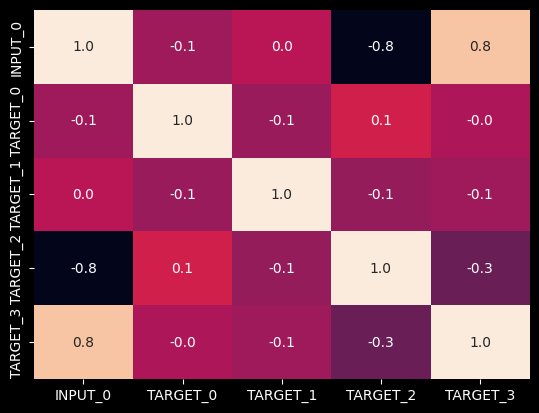

In [40]:
data = {"INPUT_0": X_pca[:, 0], 
        "TARGET_0": y_tr[:, 0], "TARGET_1": y_tr[:, 1], "TARGET_2": y_tr[:, 2], "TARGET_3": y_tr[:, 3]}
sbn.heatmap(
    pd.DataFrame(data=data).corr(), 
    cbar = False, 
    annot = True, 
    fmt=".1f"
    )

Bastano 2 componenti

In [41]:
np.cumsum(pca.explained_variance_ratio_)

array([0.95623505])

Text(0, 0.5, 'Cumulative explained variance')

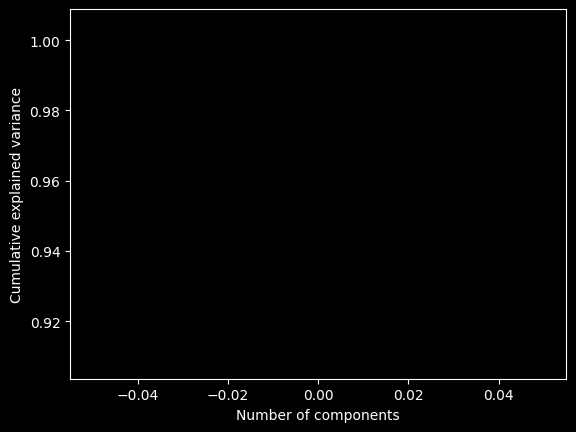

In [42]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')

Calcolo MI per le feature originali...


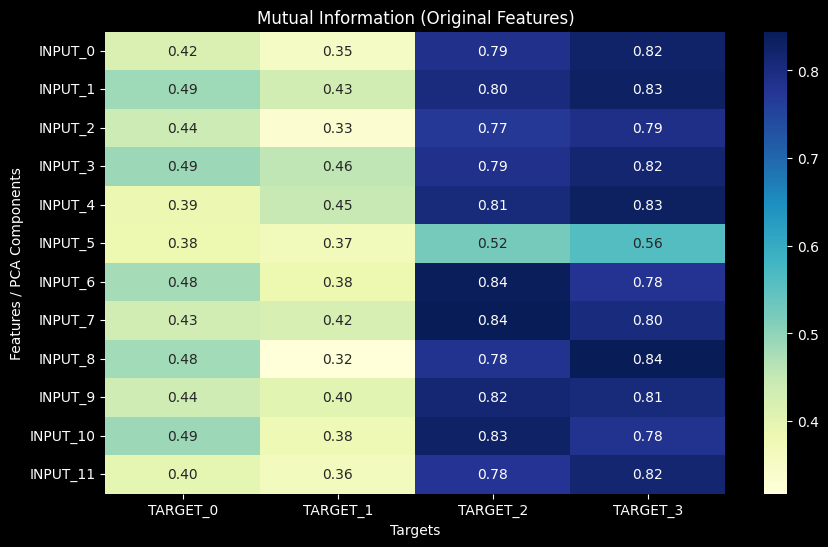

Calcolo MI per le componenti PCA...


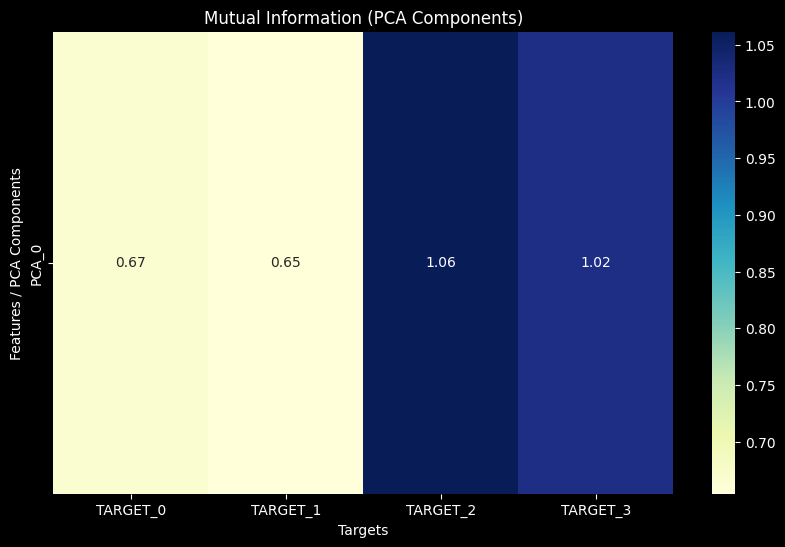

In [43]:
from sklearn.feature_selection import mutual_info_regression

def plot_mutual_information(X, y, feature_names, target_names, title="Mutual Information Scores"):
    """
    Calcola e visualizza la Mutual Information tra ogni feature e ogni target.
    """
    mi_matrix = pd.DataFrame(index=feature_names, columns=target_names)

    for col_y in target_names:
        # Calcolo della MI per il target specifico
        # random_state è importante per la riproducibilità
        mi_scores = mutual_info_regression(X, y[col_y], random_state=42)
        mi_matrix[col_y] = mi_scores

    plt.figure(figsize=(10, 6))
    sbn.heatmap(mi_matrix.astype(float), annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(title)
    plt.ylabel("Features / PCA Components")
    plt.xlabel("Targets")
    plt.show()
    
    return mi_matrix

# --- ESECUZIONE ---

# 1. MI sulle 12 feature originali (X_tr_scaled sono i tuoi dati originali scalati)
# Assumendo che X_tr_scaled sia un numpy array e y_tr pure
feature_cols = [f"INPUT_{i}" for i in range(12)]
target_cols = [f"TARGET_{i}" for i in range(4)]

print("Calcolo MI per le feature originali...")
mi_original = plot_mutual_information(
    X_tr_scaled, 
    pd.DataFrame(y_tr, columns=target_cols), 
    feature_cols, 
    target_cols,
    title="Mutual Information (Original Features)"
)

pca_names = [f"PCA_{i}" for i in range(X_pca.shape[1])]
print("Calcolo MI per le componenti PCA...")
mi_pca = plot_mutual_information(
    X_pca, 
    pd.DataFrame(y_tr, columns=target_cols), 
    pca_names, 
    target_cols,
    title="Mutual Information (PCA Components)"
)

### PCA: 2 components

In [44]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tr_scaled)

data = {"INPUT_0": X_pca[:, 0], 
        "INPUT_1": X_pca[:, 1], 
        "TARGET_0": y_tr[:, 0], "TARGET_1": y_tr[:, 1], "TARGET_2": y_tr[:, 2], "TARGET_3": y_tr[:, 3]}
pca_names = [f"PCA_{i}" for i in range(X_pca.shape[1])]

<Axes: >

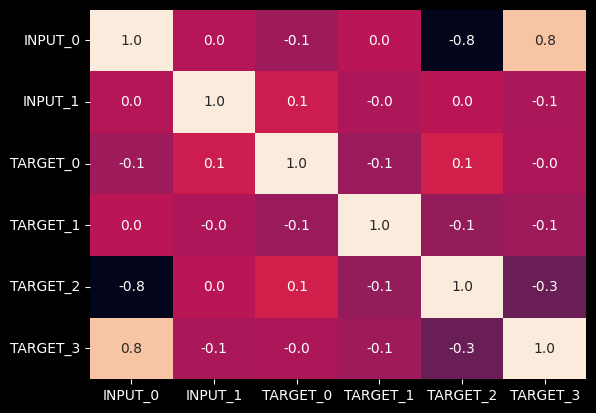

In [45]:
sbn.heatmap(
    pd.DataFrame(data=data).corr(), 
    cbar = False, 
    annot = True, 
    fmt=".1f"
    )

Calcolo MI per le componenti PCA...


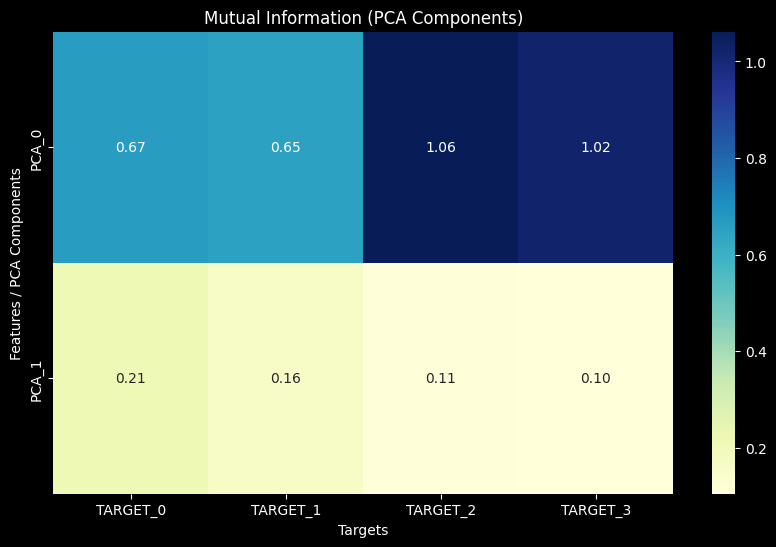

In [46]:
print("Calcolo MI per le componenti PCA...")
mi_pca = plot_mutual_information(
    X_pca, 
    pd.DataFrame(y_tr, columns=target_cols), 
    pca_names, 
    target_cols,
    title="Mutual Information (PCA Components)"
)

### PCA: 4 components

In [ ]:
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_tr_scaled)

data = {"INPUT_0": X_pca[:, 0], 
        "INPUT_1": X_pca[:, 1], 
        "INPUT_2": X_pca[:, 2], 
        "INPUT_3": X_pca[:, 3], 
        "TARGET_0": y_tr[:, 0], "TARGET_1": y_tr[:, 1], "TARGET_2": y_tr[:, 2], "TARGET_3": y_tr[:, 3]}
pca_names = [f"PCA_{i}" for i in range(X_pca.shape[1])]

<Axes: >

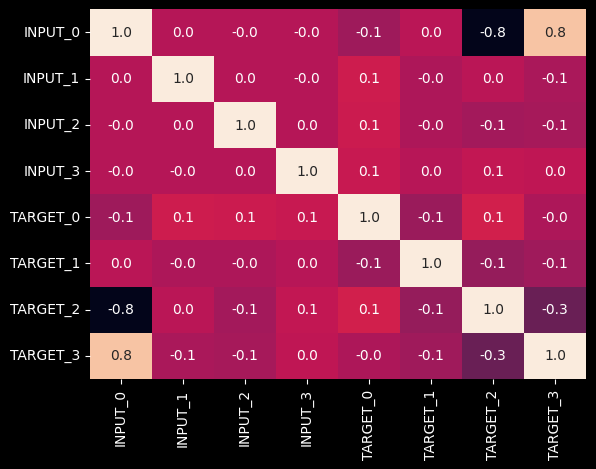

In [48]:
sbn.heatmap(
    pd.DataFrame(data=data).corr(), 
    cbar = False, 
    annot = True, 
    fmt=".1f"
    )

Calcolo MI per le componenti PCA...


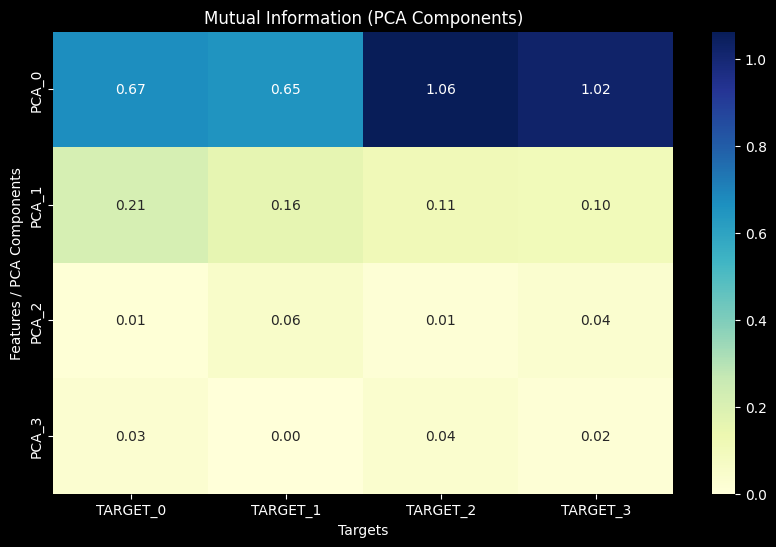

: 

In [ ]:
print("Calcolo MI per le componenti PCA...")
mi_pca = plot_mutual_information(
    X_pca, 
    pd.DataFrame(y_tr, columns=target_cols), 
    pca_names, 
    target_cols,
    title="Mutual Information (PCA Components)"
)